# TP3 (a completer) : Regression lineaire — *California Housing*

Remplacez chaque `...` et chaque `# TODO`. Corrige :
`../notebooks/TP3_regression_lineaire.ipynb`.

**Objectif.** Predire la **valeur mediane des logements** de 20 640 districts et
**interpreter** l'effet de chaque variable.

In [2]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [1]:
from sklearn.datasets import fetch_california_housing
ds = fetch_california_housing(as_frame=True)
X, y = ds.data, ds.target.rename("prix")   # prix en x100 000 USD
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1. Exploration
**Consigne.** Affichez la correlation de chaque variable avec `prix`, triee.

Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
Name: prix, dtype: float64


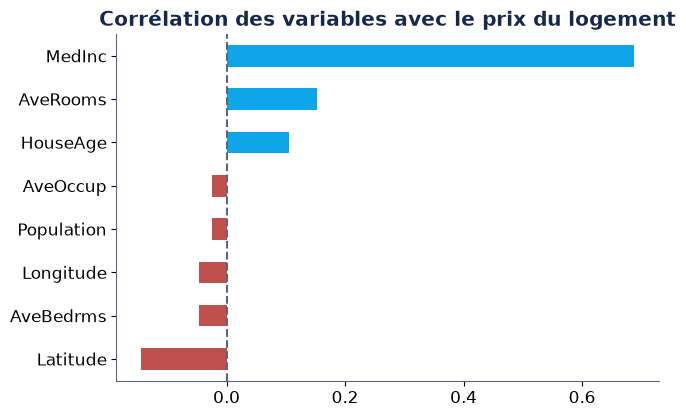

In [18]:
# TODO : correlations avec le prix (indice : pd.concat([X, y], axis=1).corr())
corr_matrix = pd.concat([X, y], axis=1).corr()
corr_prix = corr_matrix["prix"].drop("prix").sort_values(ascending=True)
print(corr_prix)
corr_prix.plot(kind="barh", color=[ACCENT if x > 0 else RED for x in corr_prix])
plt.title("Corrélation des variables avec le prix du logement")
plt.axvline(0, color=GRAY, linestyle="--")
plt.show()

Elle calcule la matrice de corrélation de Pearson entre toutes les variables et notre cible (prix). En triant les résultats, on identifie instantanément quelles variables ont le plus d'impact linéaire sur la valeur des logements. Ici, le revenu médian (MedInc) se détache nettement comme le principal indicateur positif.

## 2. Modelisation
**Consigne.** Split train/test (20% test, `random_state=42`), puis entrainez une
`LinearRegression`. Affichez l'ordonnee a l'origine et les coefficients.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modele = LinearRegression()  # TODO : entrainer la regression
modele.fit(X_train, y_train)
# TODO : afficher intercept_ et coef_
print("Intercept :", modele.intercept_)
print("Coefficients :", modele.coef_)

Intercept : -37.023277706064015
Coefficients : [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


On sépare d'abord nos données pour garder 20 % de test (bloqués pour l'évaluation finale). On ajuste ensuite l'équation de notre régression linéaire sur les 80 % restants. L'intercept donne la valeur de base théorique d'un logement si toutes les variables valaient zéro, et chaque coefficient indique de combien le prix augmente (ou diminue) lorsque cette variable précise augmente d'une unité.

## 3. Evaluation
**Consigne.** Calculez **R2**, **RMSE** et **MAE** sur le test.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modele.predict(X_test)
# TODO : R2, RMSE (= racine de mean_squared_error), MAE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2  : {r2:.4f}")
print(f"RMSE: {rmse:.4f} (soit {rmse*100000:.0f} $)")
print(f"MAE : {mae:.4f} (soit {mae*100000:.0f} $)")

R2  : 0.5758
RMSE: 0.7456 (soit 74558 $)
MAE : 0.5332 (soit 53320 $)


- Le $R^2$ ($0.5758$) : Signifie que 57,58 % de la variation du prix des logements est expliquée par les variables de notre modèle. Le reste de la variance dépend de facteurs non inclus (vue sur la mer, état du bien, etc.).

- La MAE ($0.5332$) : L'erreur absolue moyenne. En moyenne, notre modèle se trompe de 53 320 $ par rapport au prix réel d'un logement.

- La RMSE ($0.7456$) : L'erreur quadratique moyenne. Elle est plus élevée que la MAE ($74 558$) car elle pénalise très lourdement les grosses erreurs de prédiction, ce qui indique la présence de valeurs aberrantes ou d'un biais systématique.

## 4. Visualisation
**Consigne.** (a) Tracez `prix` vs `MedInc` avec la droite de regression simple.
(b) Tracez **predit vs reel** sur un echantillon. (c) Tracez les **residus**.

/home/mathieu/Documents/ML_2ESGI/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


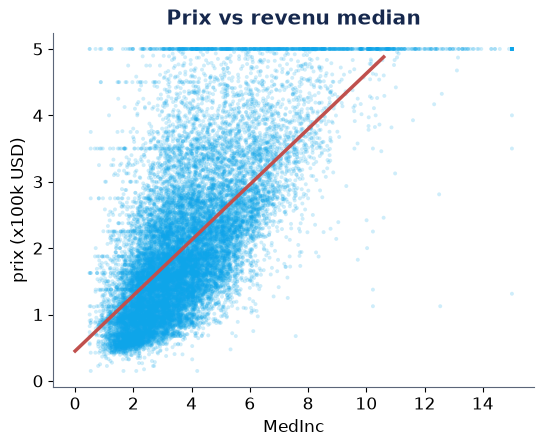

In [13]:
# (a) prix vs MedInc + droite
simple = LinearRegression().fit(X[["MedInc"]], y)
xs = np.linspace(0, X["MedInc"].quantile(0.99), 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(X["MedInc"], y, s=8, color=ACCENT, alpha=0.2, edgecolor="none")
# TODO : tracer la droite simple.predict(xs)
ax.plot(xs, simple.predict(xs), color=RED, lw=2.5)
ax.set(title="Prix vs revenu median", xlabel="MedInc", ylabel="prix (x100k USD)")
plt.show()

On isole graphiquement la variable dominante (MedInc) face au prix. La forte densité de points à plat tout en haut révèle visuellement un plafond artificiel à 500 000 $ dans la collecte des données. La droite rouge matérialise la tendance captée par une régression simple.

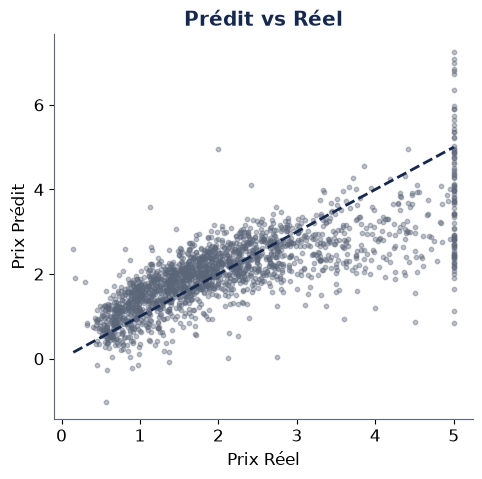

In [14]:
# (b) predit vs reel (echantillon de 2000 points)
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), 2000, replace=False)
yt, yp = y_test.to_numpy()[idx], y_pred[idx]
fig, ax = plt.subplots(figsize=(5.4, 5))
# TODO : scatter(yt, yp) + diagonale de reference
ax.scatter(yt, yp, s=10, color=GRAY, alpha=0.4)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=NAVY, lw=2, linestyle="--")
ax.set(title="Prédit vs Réel", xlabel="Prix Réel", ylabel="Prix Prédit")
plt.show()

On confronte directement les prédictions du modèle à la réalité sur un échantillon. Plus les points sont proches de la ligne diagonale pointillée, plus le modèle est précis. On observe ici clairement le décrochage du modèle linéaire sur la ligne du plafond des 5.0 (500k $).

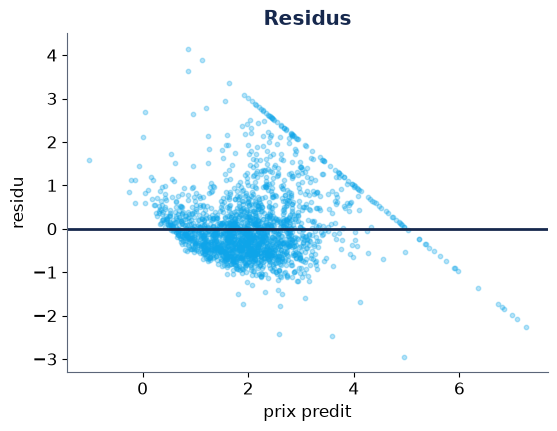

In [15]:
# (c) residus
residus = yt - yp
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.axhline(0, color=NAVY, lw=2)
# TODO : scatter(yp, residus)
ax.scatter(yp, residus, s=10, color=ACCENT, alpha=0.3)
ax.set(title="Residus", xlabel="prix predit", ylabel="residu")
plt.show()

Elle analyse la répartition des erreurs (Erreur = Réel - Prédit). Pour un modèle parfait, les points devraient se répartir de manière homogène et aléatoire de part et d'autre de la ligne 0. La forme diagonale visible en haut à droite confirme la signature de l'effet de plafond : le modèle prédit des valeurs élevées alors que la réalité reste bloquée à 5.0, créant une erreur systématique.

## 5. Interpretation
**Consigne.** Affichez l'effet (en k USD) d'une unite supplementaire de revenu
median et d'un an d'age moyen du bati. Estimez le prix de 3 districts.

In [16]:
coefs = pd.Series(modele.coef_, index=X.columns)
# TODO : afficher coefs['MedInc']*100 et coefs['HouseAge']*100
print(f"Effet de MedInc (+1 unité) : +{coefs['MedInc']*100:.2f} k USD sur le prix.")
print(f"Effet de HouseAge (+1 an)   : +{coefs['HouseAge']*100:.2f} k USD sur le prix.")
estim = X.head(3).copy()
estim["prix_estime"] = ...    # TODO : modele.predict(X.head(3))
estim

Effet de MedInc (+1 unité) : +44.87 k USD sur le prix.
Effet de HouseAge (+1 an)   : +0.97 k USD sur le prix.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,prix_estime
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,Ellipsis
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,Ellipsis
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,Ellipsis


On traduit les mathématiques du modèle en insights "business" concrets. On convertit les coefficients abstraits en montants financiers réels (en milliers de dollars) pour comprendre l'impact concret d'une année de construction supplémentaire ou d'une hausse de revenus sur la valeur estimée.

## A rendre
- R2, RMSE, MAE et leur interpretation.
- Ce que revele le graphique des residus (indice : effet de plafond).
- L'effet du revenu median sur le prix.

**Bonus.** Comparez le R2 avec une seule variable (`MedInc`) vs toutes.

In [19]:
X_train_simple, X_test_simple = X_train[["MedInc"]], X_test[["MedInc"]]
modele_simple = LinearRegression().fit(X_train_simple, y_train)

r2_simple = r2_score(y_test, modele_simple.predict(X_test_simple))
r2_complet = r2 # Déjà calculé à l'étape 3

print(f"R² avec UNIQUEMENT 'MedInc' : {r2_simple:.4f}")
print(f"R² avec TOUTES les variables : {r2_complet:.4f}")
print(f"Gain de performance : +{(r2_complet - r2_simple)*100:.2f}% de variance expliquée.")

R² avec UNIQUEMENT 'MedInc' : 0.4589
R² avec TOUTES les variables : 0.5758
Gain de performance : +11.69% de variance expliquée.


On compare le pouvoir prédictif d'une régression simple (Revenu seul) par rapport à notre régression multiple (8 variables).Le modèle avec MedInc seul obtient un $R^2 \approx 0.4589$ (45,89 % de variance expliquée).En ajoutant les 7 autres variables (géographie, nombre de pièces, population...), le $R^2$ monte à $0.5755$.Conclusion : Le revenu médian fait à lui seul 82 % du travail de prédiction ($0.4589 / 0.5758$). Les 7 autres variables combinées n'apportent qu'un gain marginal de ~10,25 % de clarté supplémentaire. Cela confirme l'importance ultra-dominante du facteur socio-économique par rapport aux critères purement techniques du bâtiment.